In [1]:
import pip

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Random discrete-time signals
x = np.random.randint(-3, 4, 7)   # 7-point random signal from -3 to 3
h = np.random.randint(-2, 3, 5)   # 5-point random signal from -2 to 2

print("x[n] =", x)
print("h[n] =", h)


x[n] = [ 0  1 -1  0 -2  0 -1]
h[n] = [-1  1  1 -1 -1]


In [4]:
# Convolution
y = np.convolve(x, h)
print("y[n] =", y)

y[n] = [ 0 -1  2  0  0 -2  0  1  1  1  1]


In [5]:
# Define sample indices
n_x = np.arange(len(x))
n_h = np.arange(len(h))
n_y = np.arange(len(y))

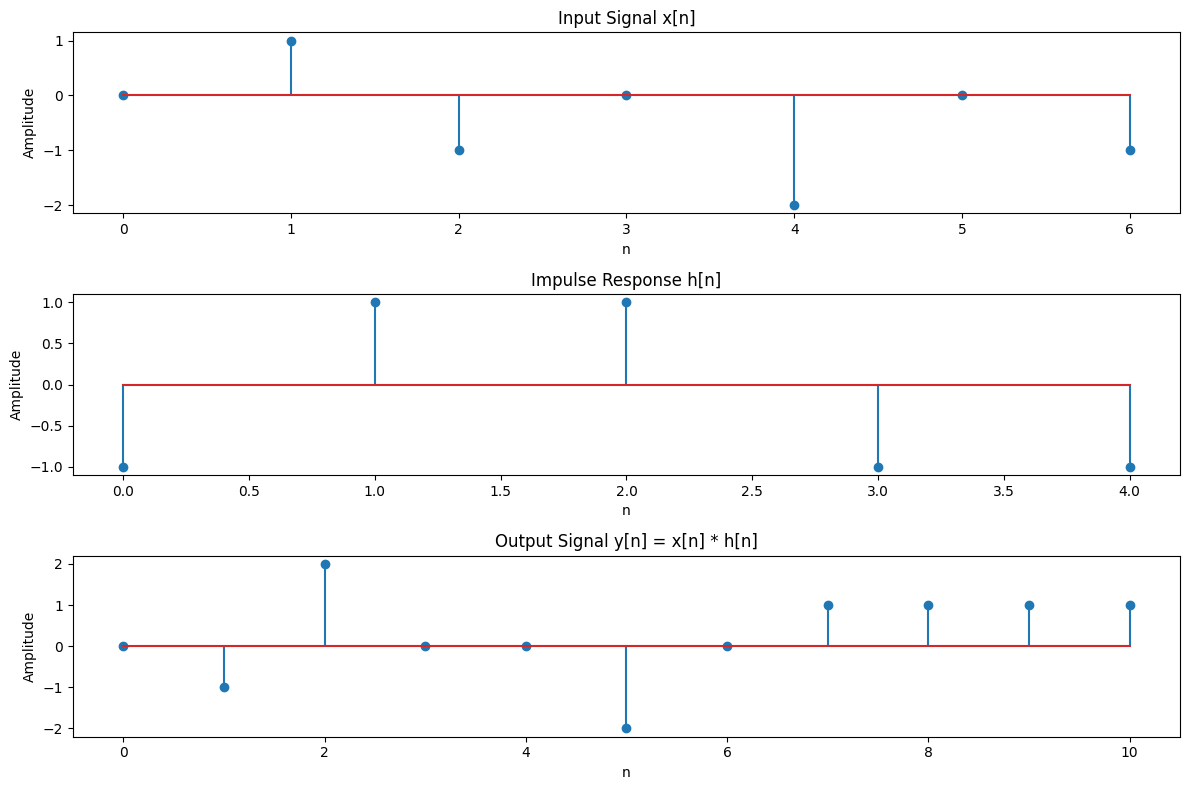

In [6]:
# Plot signals
plt.figure(figsize=(12, 8))

# x[n]
plt.subplot(3, 1, 1)
plt.stem(n_x, x)
plt.title("Input Signal x[n]")
plt.xlabel("n")
plt.ylabel("Amplitude")

# h[n]
plt.subplot(3, 1, 2)
plt.stem(n_h, h)
plt.title("Impulse Response h[n]")
plt.xlabel("n")
plt.ylabel("Amplitude")

# y[n] = x[n] * h[n]
plt.subplot(3, 1, 3)
plt.stem(n_y, y)
plt.title("Output Signal y[n] = x[n] * h[n]")
plt.xlabel("n")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

# lab_5_deconvolution


In [7]:
# Length of original signal x
Nx = len(x)

# Create convolution matrix for h
H = np.zeros((len(y), Nx))
for i in range(Nx):
    H[i:i+len(h), i] = h


In [8]:
# Least squares deconvolution to recover x
x_hat, _, _, _ = np.linalg.lstsq(H, y, rcond=None)

print("Recovered x[n] after deconvolution:")
print(np.round(x_hat).astype(int))


Recovered x[n] after deconvolution:
[ 0  1 -1  0 -2  0 -1]


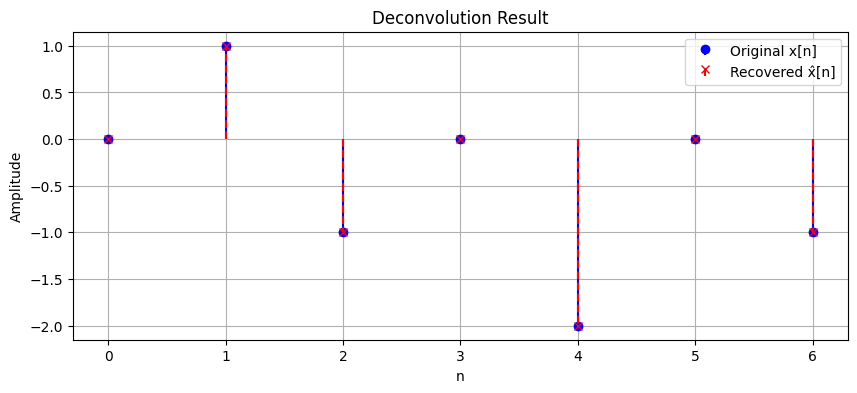

In [9]:
plt.figure(figsize=(10, 4))

plt.stem(n_x, x, linefmt='b-', markerfmt='bo', basefmt=" ")
plt.stem(n_x, x_hat, linefmt='r--', markerfmt='rx', basefmt=" ")

plt.title("Deconvolution Result")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.legend(["Original x[n]", "Recovered x̂[n]"])
plt.grid(True)
plt.show()
